# 01. Baseline

Comparison of Classic vs. Classic+hint. Motivation for the neural network approach.

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from reedsolo import RSCodec, ReedSolomonError
from rs.channels import qsc_erasure_channel

N, K, NSYM = 255, 223, 32
rsc = RSCodec(NSYM)

In [14]:
def evaluate_baseline(p_err, p_erase, num_samples=1000):
    classic_ok, hint_ok = 0, 0
    for _ in range(num_samples):
        msg = os.urandom(K)
        codeword = rsc.encode(msg)
        noisy, erase_pos = qsc_erasure_channel(codeword, p_err, p_erase)
        
        try:
            if bytes(rsc.decode(noisy)[0]) == msg:
                classic_ok += 1
        except: pass
        
        try:
            if bytes(rsc.decode(noisy, erase_pos=erase_pos)[0]) == msg:
                hint_ok += 1
        except: pass
    
    return classic_ok / num_samples, hint_ok / num_samples

In [15]:
P_ERR = 0.02
p_erase_values = [0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.14]

results = []
for p_erase in p_erase_values:
    classic, hint = evaluate_baseline(P_ERR, p_erase)
    results.append({'p_erase': p_erase, 'classic': classic, 'hint': hint})
    print(f'p_erase={p_erase}: Classic={classic:.1%}, Hint={hint:.1%}')

p_erase=0.02: Classic=96.5%, Hint=100.0%
p_erase=0.04: Classic=64.1%, Hint=98.7%
p_erase=0.06: Classic=19.9%, Hint=89.0%
p_erase=0.08: Classic=2.5%, Hint=62.0%
p_erase=0.1: Classic=0.1%, Hint=32.1%
p_erase=0.12: Classic=0.0%, Hint=11.1%
p_erase=0.14: Classic=0.0%, Hint=2.5%


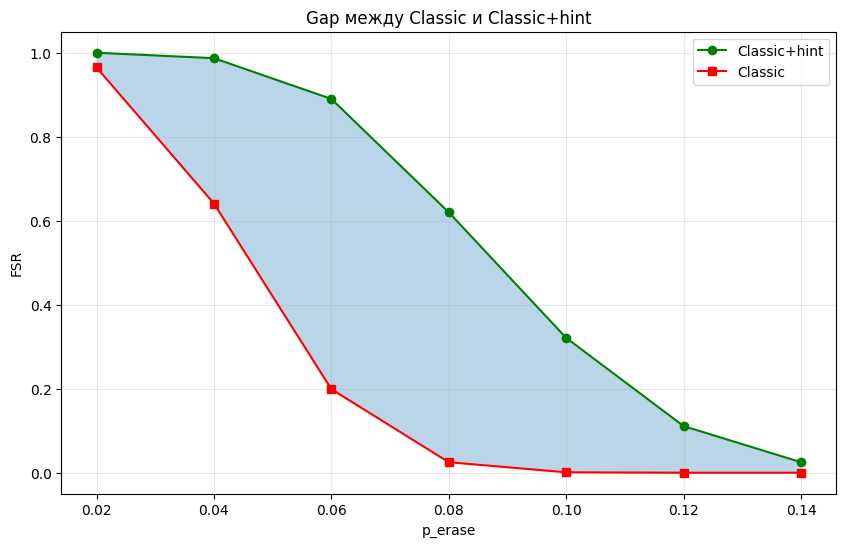

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot([r['p_erase'] for r in results], [r['hint'] for r in results], 'g-o', label='Classic+hint')
plt.plot([r['p_erase'] for r in results], [r['classic'] for r in results], 'r-s', label='Classic')
plt.fill_between([r['p_erase'] for r in results], [r['classic'] for r in results], [r['hint'] for r in results], alpha=0.3)
plt.xlabel('p_erase'); plt.ylabel('FSR'); plt.legend(); plt.grid(True, alpha=0.3)
plt.title('Gap между Classic и Classic+hint')
plt.savefig('baseline.png', dpi=150); plt.show()